<a href="https://colab.research.google.com/github/MarcelinaBytes/AIHC5020/blob/main/AIHC5020_hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 6: Cloud Data Infrastructure

###Problem 1: Loading Data from Google Cloud Storage

In [3]:
#install libraries

!pip install google-cloud-storage

In [4]:
#import everything

import pandas as pd
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials
from io import StringIO

In [5]:
storage_client = storage.Client(credentials=AnonymousCredentials())

In [6]:
#locate data

bucket = storage_client.bucket("cloud-samples-data")

blobs = bucket.list_blobs(prefix="ml-engine/")

for blob in blobs:
    if "adult.data.csv" in blob.name:
        print(blob.name)


ml-engine/census/data/adult.data.csv


In [7]:
#use provided columns

COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

In [10]:
#write required function

def load_csv_blob(blob_name, bucket, column_names=[]):
    """
    Loads a CSV file from a Google Cloud Storage bucket into a pandas DataFrame.

    Parameters:
        blob_name (str): Path to the CSV file inside the bucket
        bucket (google.cloud.storage.bucket.Bucket): GCS bucket object
        column_names (list): Optional list of column names

    Returns:
        pandas.DataFrame
    """

    # 1. Create the blob object
    blob = bucket.blob(blob_name)

    # 2. Download the CSV as text
    csv_text = blob.download_as_text()

    # 3. Read CSV text into a DataFrame
    if column_names:
        df = pd.read_csv(StringIO(csv_text), names=column_names)
    else:
        df = pd.read_csv(StringIO(csv_text))

    # 4. Return the DataFrame
    return df

In [12]:
#verify

blob_name = "ml-engine/census/data/adult.data.csv"

df = load_csv_blob(
    blob_name=blob_name,
    bucket=bucket,
    column_names=COLUMN_NAMES
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##Problem 2: Querying from BigQuery

In [41]:
#install libraries

!pip install google-cloud-bigquery

In [42]:
#imports

import pandas as pd
from google.cloud import bigquery
from google.colab import auth

In [45]:
#authenticate colab environment

from google.colab import auth
auth.authenticate_user()


In [46]:
import pandas as pd
from google.cloud import bigquery

In [47]:
PROJECT_ID = "savvy-parser-422115"

bq_client = bigquery.Client(project=PROJECT_ID)

In [49]:
covid_query = """
SELECT
  date,
  new_confirmed,
  new_deceased
FROM
  `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
  country_name = 'Mexico'
  AND date BETWEEN '2021-01-01' AND '2021-12-31'
ORDER BY
  date ASC
"""

In [50]:
covid_query_job = bq_client.query(covid_query)

In [51]:
covid_df = covid_query_job.to_dataframe()

In [52]:
print("Number of rows:", len(covid_df))

Number of rows: 911770


In [53]:
covid_df.head()

,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


In [54]:
covid_df["date"].min(), covid_df["date"].max()

(datetime.date(2021, 1, 1), datetime.date(2021, 12, 31))

In [55]:
covid_df.columns

Index(['date', 'new_confirmed', 'new_deceased'], dtype='object')

##Problem 3: Aggregating and Visualizing the Data

In [57]:
mexico_covid_df = covid_df.copy()

In [58]:
mexico_covid_df.head()

,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


In [59]:
#create month column

mexico_covid_df['month'] = mexico_covid_df['date'].apply(lambda d: d.month)

In [60]:
#aggregate

monthly_covid = (
    mexico_covid_df
    .groupby('month')[['new_confirmed', 'new_deceased']]
    .sum()
    .reset_index()
)

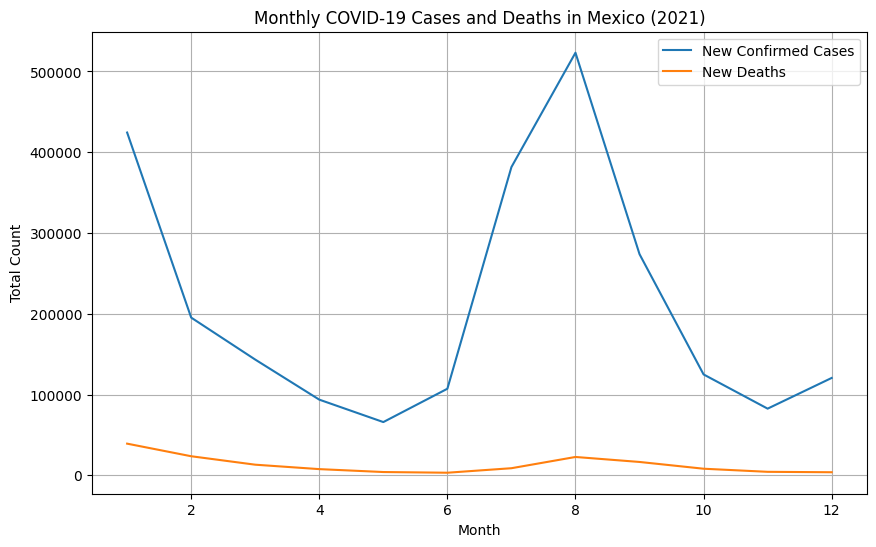

In [61]:
#plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(monthly_covid['month'], monthly_covid['new_confirmed'], label='New Confirmed Cases')
plt.plot(monthly_covid['month'], monthly_covid['new_deceased'], label='New Deaths')
plt.title('Monthly COVID-19 Cases and Deaths in Mexico (2021)')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.legend()
plt.grid(True)
plt.show()